In [1]:
library(vcfR)
library(genetics)
suppressMessages(library(tidyverse))
suppressMessages(library(data.table))
suppressMessages(library(BEDMatrix))
suppressMessages(library(glue))
suppressMessages(library(bedr))

suppressMessages(library(vcfR))
suppressMessages(library(genetics))


   *****       ***   vcfR   ***       *****
   This is vcfR 1.15.0 
     browseVignettes('vcfR') # Documentation
     citation('vcfR') # Citation
   *****       *****      *****       *****


Loading required package: combinat


Attaching package: 'combinat'


The following object is masked from 'package:utils':

    combn


Loading required package: gdata


Attaching package: 'gdata'


The following object is masked from 'package:stats':

    nobs


The following object is masked from 'package:utils':

    object.size


The following object is masked from 'package:base':

    startsWith


Loading required package: gtools

Loading required package: MASS

Loading required package: mvtnorm




NOTE: THIS PACKAGE IS NOW OBSOLETE.





  The R-Genetics project has developed an set of enhanced genetics


  packages to replace 'genetics'. Please visit the project homepage


  at http://rgenetics.org for informtion.






Attaching package: 'genetics'


The following objects are masked from 

In [2]:
getLDMatrix <- function(region){
    chrom <- (region %>% str_split(., pattern=':'))[[1]][1]
    vcf_file <- "/project/yangili1/cdai/genome_index/hs38/GTEx_v7/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz"  
    gt_region <- bedr::tabix(region = region, file = vcf_file) %>% 
        filter(FORMAT == 'GT')

    rownames(gt_region) <- gt_region$ID
    
    gt_filtered <- gt_region %>%
      mutate(AF = as.numeric(str_extract(INFO, "(?<=AF=)[0-9.]+"))) %>%
      filter(AF >= 0.05)

    # Select columns starting with "GTEX-"
    gt_region <- gt_filtered[, grepl("^GTEX-", colnames(gt_filtered))]

    gt_region <- gt_region[((gt_region == '.|.') %>% rowSums()) <= 838/20,]
    
    gt_region[gt_region == "0|0"] <- 0
    gt_region[(gt_region == "1|0") | (gt_region == "0|1")] <- 1
    gt_region[gt_region == "1|1"] <- 2
    gt_region[gt_region == ".|."] <- NA
    
#     return(gt_region)

    matrix_data_int <- gt_region %>% mutate_all(as.integer) #suppressWarnings(as.integer(gt_region))

    # Reshape into the original matrix structure
#     matrix_data_int <- matrix(matrix_data_int, nrow = nrow(gt_region), dimnames = dimnames(gt_region))

    imputed_data <- apply(matrix_data_int, 2, function(x) ifelse(is.na(x), mean(x, na.rm = TRUE), x))
    X <- imputed_data %>% t() %>% cor()

    row_variances <- apply(imputed_data, 1, var)

    # Filter rows with non-zero variance
    filtered_matrix <- imputed_data[row_variances != 0, , drop = FALSE]

    LD <- filtered_matrix %>% t() %>% cor()
    return (LD)
}

In [8]:
LD <- getLDMatrix("chr12:57214648-58212395")

TABIX-QUERY
 * Processing input (1): 
CONVERT TO BED
 * Checking input type... PASS
   Input is in index format
VALIDATE REGIONS
 * Check if index is a string... PASS
 * Check index pattern... PASS
 * Check for missing values... PASS
 * Check for larger start position... PASS.
 * Check if zero based... PASS
 * Checking sort order... PASS
 * Checking for overlapping 'contiguous' regions... PASS

bash -c 'tabix  /project/yangili1/cdai/genome_index/hs38/GTEx_v7/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz -R /tmp//RtmpLJ6j05/_2fd916336e016d.bed '


In [12]:
LD %>% as.data.frame(.) %>% write_tsv(., '../code/results/coloc/LD/chr12_57713053_N_N_IMSGC2019.tsv.gz')

In [13]:
LD <- getLDMatrix("chr11:303145-1302841")

TABIX-QUERY
 * Processing input (1): 
CONVERT TO BED
 * Checking input type... PASS
   Input is in index format
VALIDATE REGIONS
 * Check if index is a string... PASS
 * Check index pattern... PASS
 * Check for missing values... PASS
 * Check for larger start position... PASS.
 * Check if zero based... PASS
 * Checking sort order... PASS
 * Checking for overlapping 'contiguous' regions... PASS

bash -c 'tabix  /project/yangili1/cdai/genome_index/hs38/GTEx_v7/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz -R /tmp//RtmpLJ6j05/_2fd9165d79af7.bed '


In [15]:
LD %>% as.data.frame(.) %>% write_tsv(., '../code/results/coloc/LD/chr11_803017_N_N_GCST004988.tsv.gz')

In [4]:
LD <- getLDMatrix("chr11:177470-1078618")

TABIX-QUERY
 * Processing input (1): 
CONVERT TO BED
 * Checking input type... PASS
   Input is in index format
VALIDATE REGIONS
 * Check if index is a string... PASS
 * Check index pattern... PASS
 * Check for missing values... PASS
 * Check for larger start position... PASS.
 * Check if zero based... PASS
 * Checking sort order... PASS
 * Checking for overlapping 'contiguous' regions... PASS

bash -c 'tabix  /project/yangili1/cdai/genome_index/hs38/GTEx_v7/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz -R /tmp//Rtmp9SyfOK/_30096c189df504.bed '


In [5]:

LD %>% as.data.frame(.) %>% write_tsv(., '../code/results/coloc/LD/chr11_578759_N_N_Hypothyroidism.tsv.gz')

In [3]:
LD <- getLDMatrix("chr17:43615230-44613099")

TABIX-QUERY
 * Processing input (1): 
CONVERT TO BED
 * Checking input type... PASS
   Input is in index format
VALIDATE REGIONS
 * Check if index is a string... PASS
 * Check index pattern... PASS
 * Check for missing values... PASS
 * Check for larger start position... PASS.
 * Check if zero based... PASS
 * Checking sort order... PASS
 * Checking for overlapping 'contiguous' regions... PASS

bash -c 'tabix  /project/yangili1/cdai/genome_index/hs38/GTEx_v7/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz -R /tmp//Rtmpoui62Z/_2ff2a711fb8563.bed '


In [4]:
LD %>% as.data.frame(.) %>% write_tsv(., '../code/results/coloc/LD/chr17_44114525_N_N_bipolar_disorder.tsv.gz')

In [2]:
vcf_file <- "/project/yangili1/cdai/genome_index/hs38/GTEx_v7/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz"  #   # Replace with the path to your VCF file
region <- "chr12:57214648-58212395"  # Replace with your region of interest


In [3]:
vcf <- read.vcfR(vcf_file)

# Extract genotype data
gt <- extract.gt(vcf, element = "GT")  # Extract genotype calls
positions <- vcf@fix[, "POS"]  # Get variant positions
chromosome <- vcf@fix[, "CHROM"]

# Parse the region
region_split <- strsplit(region, "[:-]")[[1]]
region_chr <- region_split[1]
region_start <- as.numeric(region_split[2])
region_end <- as.numeric(region_split[3])


In [ ]:
# Subset the region
region_indices <- which((chromosome == region_chr) & 
                        (as.numeric(positions) >= region_start) & 
                        (as.numeric(positions) <= region_end))
gt_region <- gt[region_indices, ]

# # Convert genotype calls to numeric allele counts for filtering
# convert_genotype <- function(genotype) {
#   alleles <- strsplit(genotype, "[|/]")[[1]]
#   if (any(alleles == ".")) return(NA)  # Handle missing data
#   alleles <- as.numeric(alleles)
#   return(sum(alleles))
# }
# geno_matrix <- apply(gt_region, 2, function(col) {
#   sapply(col, convert_genotype)
# })


In [ ]:
strsplit(gt_region[,1], "[|/]")[[1]]

In [ ]:
gt_region

geno_matrix_clean <- gt_region
geno_matrix_clean[geno_matrix_clean == "0|0"] <- 0
geno_matrix_clean[geno_matrix_clean == "0|1"] <- 1
geno_matrix_clean[geno_matrix_clean == "1|0"] <- 1
geno_matrix_clean[geno_matrix_clean == "1|1"] <- 2
geno_matrix_clean <- as.numeric(geno_matrix_clean)

In [53]:
library(plink2R)

Loading required package: Rcpp

Loading required package: RcppEigen



In [48]:
vcf <- read.vcfR(vcf_file)

Scanning file to determine attributes.
File attributes:
  meta lines: 3387
  header_line: 3388
  variant count: 511411
  column count: 30
Meta line 3387 read in.
All meta lines processed.
gt matrix initialized.
Character matrix gt created.
  Character matrix gt rows: 511411
  Character matrix gt cols: 30
  skip: 0
  nrows: 511411
  row_num: 0
Processed variant: 511411
All variants processed


In [49]:
# Define the region
chrom <- "chr1" # Replace with your chromosome
start <- 100000  # Start position
end <- 200000    # End position

# Subset the VCF
region_vcf <- vcf[vcf@fix[, "CHROM"] == chrom & as.numeric(vcf@fix[, "POS"]) >= start & as.numeric(vcf@fix[, "POS"]) <= end, ]


In [50]:
write.vcf(region_vcf, file = "subset.vcf")

# Convert VCF to PLINK binary format (use the system command for PLINK2)
system("plink2 --vcf subset.vcf --make-bed --out subset")


Warning message in system("plink2 --vcf subset.vcf --make-bed --out subset"):
"error in running command"


In [59]:
link_data <- read_plink("subset.bed", "subset.bim", "subset.fam")

# Extract the genotype matrix
geno_matrix <- plink_data$bed

# Calculate the LD matrix
ld_matrix <- cor(geno_matrix)

ERROR: Error in match.arg(impute): 'arg' should be one of "none", "avg", "random"


In [ ]:
plink --vcf your_file.vcf --chr chr1 --from-bp 100000 --to-bp 200000 --make-bed --out region_subset



CHR_A,BP_A,SNP_A,CHR_B,BP_B,SNP_B,R2
<int>,<int>,<chr>,<int>,<int>,<chr>,<dbl>
1,109534,chr1_109534_A_C_b38,1,115746,chr1_115746_C_T_b38,1
1,109534,chr1_109534_A_C_b38,1,135203,chr1_135203_G_A_b38,1
1,115746,chr1_115746_C_T_b38,1,135203,chr1_135203_G_A_b38,1
1,126108,chr1_126108_G_A_b38,1,133160,chr1_133160_G_A_b38,1
1,126108,chr1_126108_G_A_b38,1,134234,chr1_134234_G_A_b38,1
1,126108,chr1_126108_G_A_b38,1,135032,chr1_135032_G_A_b38,1


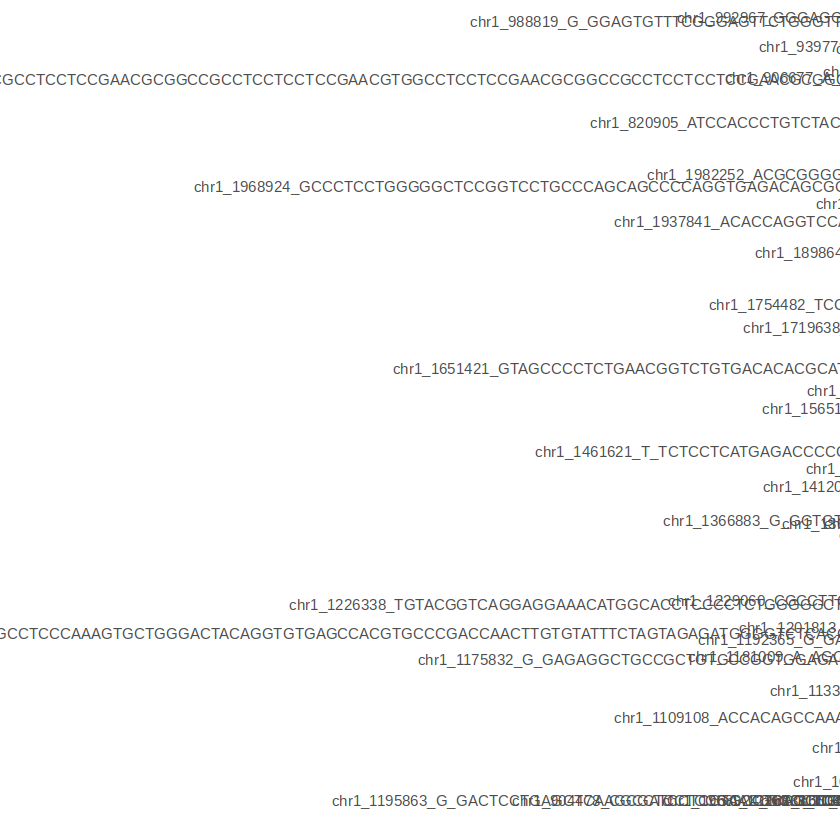

In [64]:
# Load required libraries
library(data.table)
library(ggplot2)
library(reshape2)

# Load the LD file
ld_data <- fread("ld_matrix.ld", header = TRUE)

# Check the structure of the file
head(ld_data)

# Extract SNPs and LD values
ld_matrix <- dcast(ld_data, SNP_A ~ SNP_B, value.var = "R2")

# Convert to matrix
ld_matrix <- as.matrix(ld_matrix[, -1])  # Remove SNP_A column for matrix conversion
rownames(ld_matrix) <- ld_data$SNP_A[!duplicated(ld_data$SNP_A)]

# Visualize the LD matrix
ld_melt <- melt(ld_matrix, na.rm = FALSE)
ggplot(data = ld_melt, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0, limit = c(0, 1), space = "Lab") +
  theme_minimal() +
  labs(x = "SNPs", y = "SNPs", fill = "LD (R²)")


In [1]:
suppressMessages(library(data.table))
suppressMessages(library(tidyverse))
suppressMessages(library(BEDMatrix))
suppressMessages(library(glue))

Warning message:
"'timedatectl' indicates the non-existent timezone name 'n/a'"


In [2]:
for(file in list.files("/project/yangili1/cfbuenabadn/leafcutter2_paper/code/LeafCutter2_ColocBoost_GTEx/final_checking/", 
                       pattern = ".R", full.names = T)){ source(file) }
source("/project/yangili1/cfbuenabadn/leafcutter2_paper/code/LeafCutter2_ColocBoost_GTEx/preprocess_functions.R")



In [3]:
ld <- extract_ld_blocks('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/resources/ADSP_LD_matrix/', chr = 'chr1', gene.start = 100000, gene.end = 200000)
LD <- as.matrix(Reduce(Matrix::bdiag, ld))
ld.variants <- unlist(sapply(ld, rownames))

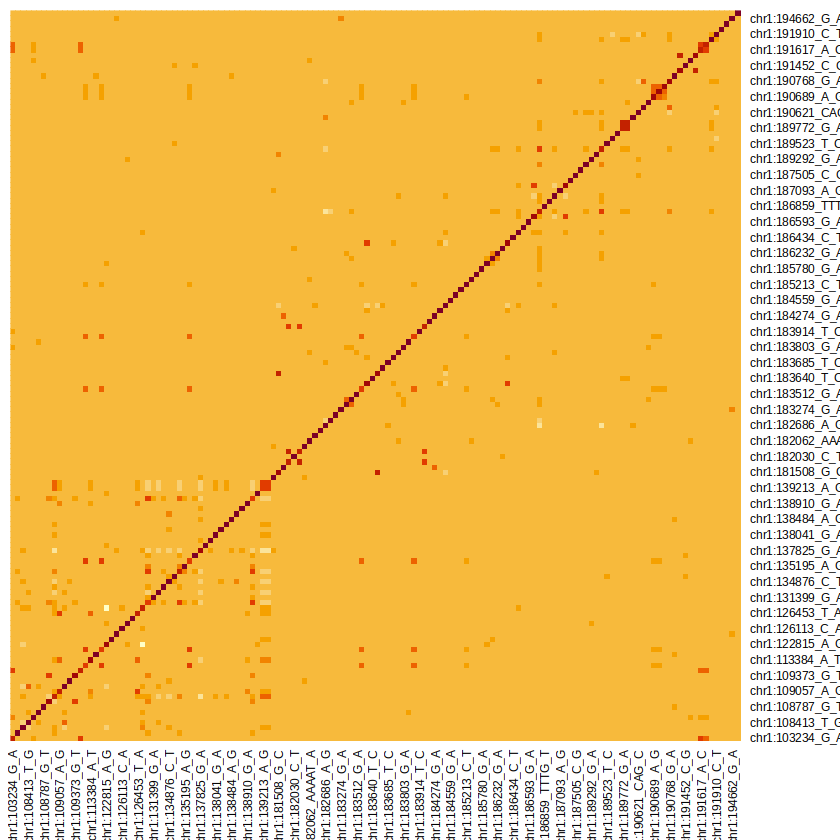

In [100]:
LD %>% heatmap(Rowv = NA, Colv = NA, )

In [101]:
LD

,chr1:103234_G_A,chr1:104030_G_A,chr1:104033_T_C,chr1:108413_T_G,chr1:108582_G_A,chr1:108630_A_G,chr1:108787_G_T,chr1:108826_G_C,chr1:108893_C_T,chr1:109057_A_G,⋯,chr1:191529_G_A,chr1:191600_G_A,chr1:191617_A_C,chr1:191645_A_G,chr1:191859_C_T,chr1:191910_C_T,chr1:191926_T_C,chr1:194633_G_C,chr1:194662_G_A,chr1:197326_G_A
chr1:103234_G_A,1.000000,0.000585,-0.054552,-0.027549,0.203512,-0.011064,0.010814,-0.001302,0.004289,-0.005381,⋯,0.003452,0.042527,0.757123,0.706218,-0.018663,-0.008731,-0.001822,-0.034075,-0.012666,-0.003476
chr1:104030_G_A,0.000585,1.000000,-0.002052,0.016087,-0.003942,0.009376,-0.003855,-0.015432,0.056371,-0.001333,⋯,-0.004198,-0.003998,0.001562,-0.000915,-0.008049,-0.011210,-0.004261,-0.006908,-0.004162,0.009033
chr1:104033_T_C,-0.054552,-0.002052,1.000000,-0.207933,-0.013921,-0.026178,0.002093,-0.114511,0.096855,0.010794,⋯,0.000474,-0.014230,-0.044675,-0.040479,-0.000945,-0.008976,0.000298,0.011953,0.005402,-0.001296
chr1:108413_T_G,-0.027549,0.016087,-0.207933,1.000000,-0.008475,0.074648,0.003954,-0.000624,0.004262,-0.007703,⋯,-0.001992,-0.002627,-0.012421,-0.010249,-0.005468,0.008754,-0.005745,0.009671,0.002782,0.004392
chr1:108582_G_A,0.203512,-0.003942,-0.013921,-0.008475,1.000000,0.009888,-0.002371,0.001965,-0.014673,0.001448,⋯,0.046560,-0.002458,0.138074,0.117330,-0.007871,-0.016218,-0.002556,-0.004864,-0.002528,-0.002817
chr1:108630_A_G,-0.011064,0.009376,-0.026178,0.074648,0.009888,1.000000,-0.007239,0.011060,0.004829,-0.015841,⋯,-0.007503,0.009330,-0.006381,-0.006125,-0.007582,0.003876,-0.007802,0.001835,-0.007823,-0.001095
chr1:108787_G_T,0.010814,-0.003855,0.002093,0.003954,-0.002371,-0.007239,1.000000,0.007403,0.026480,0.001858,⋯,-0.002459,-0.002401,0.005077,0.006322,-0.007895,-0.005983,-0.002498,0.002463,-0.002393,-0.002601
chr1:108826_G_C,-0.001302,-0.015432,-0.114511,-0.000624,0.001965,0.011060,0.007403,1.000000,-0.148475,-0.011938,⋯,0.005407,-0.008340,-0.003250,-0.002483,-0.004098,-0.001104,-0.009025,-0.004048,-0.009101,-0.002194
chr1:108893_C_T,0.004289,0.056371,0.096855,0.004262,-0.014673,0.004829,0.026480,-0.148475,1.000000,0.102391,⋯,0.009180,-0.000694,0.001474,-0.001646,0.001848,0.003736,0.000964,-0.008619,0.002761,0.001706
chr1:109057_A_G,-0.005381,-0.001333,0.010794,-0.007703,0.001448,-0.015841,0.001858,-0.011938,0.102391,1.000000,⋯,0.000724,0.009774,0.000680,0.001003,0.011321,0.001995,-0.007720,-0.007617,0.008905,0.014261


In [105]:
gt_region[gt_region == "0|0"] <- 0
gt_region[(gt_region == "1|0") | (gt_region == "0|1")] <- 1
gt_region[gt_region == "1|1"] <- 2


In [106]:
gt_region %>% as.integer()

[1]  0  0  1  1  0  1  1  1  0  0  0  0  0  1  0  0  0  1  0  0  0  2  0  0
   [25]  0  2  2  2  2  2  2  2  2  1  0  0  0  1  1  0  0  0  0  0  0  0  0  0
   [49]  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   [73]  0  1  0  1  0  1  0  0  0  0  0  0  0  0  0  0  0  1  1  0  0  0  0  0
   [97]  0  0  0  1  0  0  2  0  0  0  2  2  0  0  0  0  0  0  2  2  2  0  0  0
  [121]  1  2  0  0  0  1  0  0  0  1  1  0  1  1  0  0  0  1  0  0  1  1  2  1
  [145]  0  1  1  1  1  1  1  0  0  0  1  0  0  0  2  1  1  0  0  0  1  0  1  1
  [169]  0  1  2  1  0  0  0  1  0  0  1  0  1  0  1  1  1  1  1  1  1  0  0  2
  [193]  0  0  1  0  2  0  2  0  0  1  1  1  2  1  0  1  0  2  2  1  1  2  1  0
  [217]  1  0  0  0  1  1  1  2  2  2  1  0  1  0  0  1  0  2  1  0  0  2  1  0
  [241]  0  1  0  1  1  0  0  0  1  0  1  2  0  2  0  2  0  0  0  0  0  0  0  0
  [265]  0  0  2  0  0  0  0  0  2  0  0  0  0  0  0  0  1  0  0  1  2  2  2  2
  [289]  2  2  0  2  0  0  2  2  2  2  0  0  2  2  2  1  1 NA  1  1  1  1  1  2
  [313]  1  1  2  1  1  1  1  1  1  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  [337]  0  0  0  1  0  0  0  2  0  0  1  0  2  1  0  2  2  0  2  0  2  2  2  2
  [361]  2  1  0  1  1  0  1  1  0  0  1  2  1  0  0  1  1  1  1  2  2  0  0  2
  [385]  0  0  1  1  0  1  0  2  1  2  0  0  0  0  0  1  1  2  0  0  0  0  0  1
  [409]  1  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  2  2  0  0  0
  [433]  0  2  1  1  1  1  2  2  0  2  1  1  0  0  2  0  2  1  2  0  1  1  2  2
  [457]  0  2  2  1  0  1  0  1  2  0  1  2  0 NA  2  1  1  1  0  2  0  2  0  2
  [481]  2  2  0  1  0  0  2  2  1  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  [505]  2  2  2  2  0  2  1  1  0  2  2  2  2  1  2  1  1  0  2  2  2  0  2  0
  [529]  2  0  0  1  2  2  0  0  1  2  1  0  2  0  1  2  1  0  1  1  0  0  1  0
  [553]  0  1  0  1  1  1  1  1  1  1  0  1  0  0  2  0  1  1  0  1  0  1  1  1
  [577]  0  0  1  0  0  1  1  2  1  0  1  1  1  1  1  1  1  0  1  0  0  0  1  1
  [601]  1  1  1  0  1  1  0  0  1  1  1  1  1  1  1  1  1  0  0  0  1  1  1  1
  [625]  1  1  1  1  1  0  0  1  2  1  0  1  1  1  1  1  0  0  0  1  0  1  1  0
  [649]  1  0  0  0  0  1  0  0  0  0  1  0  1  2  2  0  2  0  1  0  1  1  1  1
  [673]  1  0  2  2  1  0  1  0  1  1  2  2  2  2  2  2  2  2  2  1  1  2  1  1
  [697]  1  2  1  1  2  2  1  1  0  2  2  2  0  1  1  0  0  1  0  1  1  1  2  1
  [721]  1  1  1  1  1  1  0  0  0  0  0  0  2  0  0  1  1  2  2  2  0  0  0  1
  [745]  2  2  2  1  2  2  2  2  2  2  2  2  2  2  2  2  2  1  2  2  2  1  1  0
  [769]  0  2  1  0  1  2  2  0  1  1  0  0  2  0  0  2  0  0  0  1  0  2  2  2
  [793]  2  1  1  2  2  2  2  2  0  1  0  0  2  2  2  0  2  1  2  2  0  0  0  1
  [817]  0  0  0  2  1  0  0  0  0  0  0  0  0  2  1  0  0  1  0  1  0  0  0  1
  [841]  0  2  1  1  1  1  0  1  0  1  0  1  0  0  0  0  1  1  1  1  1  1  1  1
  [865]  1  1  0  0  1  2  1  0  1  2  1  1  0  1  1  1  1  0  1  1  0  2  1  1
  [889]  2  0  1  1  1  1  1  1  1  1  0 NA NA  0  0  0  0  1  1  1  1  1  0  1
  [913]  1  1  1  1  1  1  1  1  1  1  1  1  0  1  1  1  1  1  0  1  1  0  0  0
  [937]  1  0  1  1  1  1  0  0  0  1  1  1  1  1  1  1  1  1  1  0  2  0  1  1
  [961]  0  1  1  1  1  1  1  0  1  1  1  0  0  0  1  1  1  0  1  1  0  0  0  0
  [985]  0  0  0  0  1  2  0  0  0  0  0  1  0  0  0  0  0  0  1  0  1  2  1  1
 [1009]  2  2  0  2  1  0  1  1  0  0  1  0  0  0  0  0  0  1  0  0  0  2  0  0
 [1033]  0  1  1  0  1  0  1  0  1  0  0  0  1  0  2  2  0  1  0  0  1  0  1  1
 [1057]  0  0  1  1  1  1  0  1  0  0  1  0  1  1  1  1  1  0  1  2  1  1  2  1
 [1081]  1  1  1  1  1  0  1  1  1  1  1  1  1  1  1  0  0  1  1  1  1  1  1  1
 [1105]  0  1  1  2  0  1  1  0  1  1  1  2  0  1  1  1  0  0  2  2  1  1  0  1
 [1129]  0  1  0  1  0  1  0  0  0  1  0  0  1  0  0  0  0  0  0  0  0  0  2  0
 [1153]  0  0  0  0  0  1  0  0  1  0  0  0  1  1  0  0  2  2  1  1  1  0  2  1
 [1177]  1  0  0  0  0  1  0  1  1  0  1  0  0  1  0  0  1  0  1  1  1  1  0  1
 [12

In [107]:
matrix_data_int <- suppressWarnings(as.integer(gt_region))

# Reshape into the original matrix structure
matrix_data_int <- matrix(matrix_data_int, nrow = nrow(gt_region), dimnames = dimnames(gt_region))


In [108]:
imputed_data <- apply(matrix_data_int, 2, function(x) ifelse(is.na(x), mean(x, na.rm = TRUE), x))
X <- imputed_data %>% t() %>% cor()

Warning message in cor(.):
"the standard deviation is zero"


In [91]:
imputed_data %>% t() %>% cov() %>% heatmap()

In [109]:
row_variances <- apply(imputed_data, 1, var)

# Filter rows with non-zero variance
filtered_matrix <- imputed_data[row_variances != 0, , drop = FALSE]

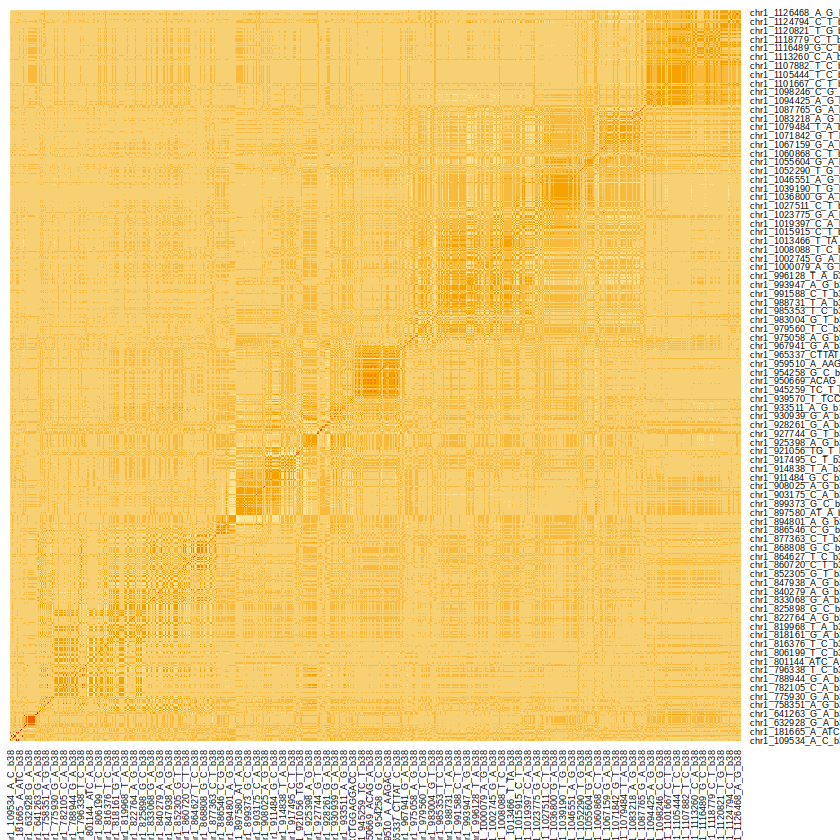

In [114]:
filtered_matrix %>% head(1000) %>% t() %>% cor() %>% heatmap(Rowv = NA, Colv = NA, )